##[DF26] df dot - Learning Progress Prediction

### 1. Cài đặt thư viện


In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import plot_model

### 2. Set seed

In [2]:
tf.keras.utils.set_random_seed(76)
tf.config.experimental.enable_op_determinism()

### 3. Tải dữ liệu

In [3]:
if 'google.colab' in str(get_ipython()):
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/df-dot/data'
else:
    BASE_DIR = './'

path_admission = os.path.join(BASE_DIR, 'admission.csv')
path_records = os.path.join(BASE_DIR, 'academic_records.csv')
path_test = os.path.join(BASE_DIR,'test.csv')

df_admission = pd.read_csv(path_admission)
df_records = pd.read_csv(path_records)
df_test = pd.read_csv(path_test)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 4. Tiền xử lý dữ liệu & Tạo đặc trưng

In [4]:
def extract_semester_and_year(date_str):
    date_arr = date_str.split()
    semester = int(date_arr[0][-1:])
    year = int(date_arr[1].split('-')[0])
    return pd.Series([semester, year])

df_records[['HOC_KY', 'NAM_HOC']] = df_records['HOC_KY'].apply(extract_semester_and_year)
df_test[['HOC_KY', 'NAM_HOC']] = df_test['HOC_KY'].apply(extract_semester_and_year)

for col in ['GPA', 'CPA', 'TC_HOANTHANH']:
    df_test[col] = np.nan

df = pd.concat([df_records, df_test], axis=0, ignore_index=True)
df = df.merge(df_admission, on='MA_SO_SV', how='left')
df = df.sort_values(by=['MA_SO_SV', 'NAM_HOC', 'HOC_KY'])
df = df.drop_duplicates()

group_st = df.groupby('MA_SO_SV')

# Xử lý ngoại lệ GPA/CPA
df['CPA'] = df['CPA'].clip(upper=4.0)
df['GPA'] = df['GPA'].clip(upper=4.0)

df['GPA_KY_TRUOC'] = group_st['GPA'].shift(1)
df['CPA_KY_TRUOC'] = group_st['CPA'].shift(1)
df['TC_NO'] = df['TC_DANGKY'] - df['TC_HOANTHANH']
df['TC_NO_KY_TRUOC'] = group_st['TC_NO'].shift(1).fillna(0)

avg_credit = group_st['TC_DANGKY'].transform(lambda x: x.shift(1).expanding().mean())
df['TL_TC_DANGKY'] = (df['TC_DANGKY'] / (avg_credit + 1)).fillna(1.0)
df['SO_NAM_HOC'] = df['NAM_HOC'] - df['NAM_TUYENSINH'] + 1

# Tỷ lệ hoàn thành
df['TEMP_RATE'] = df['TC_HOANTHANH'] / df['TC_DANGKY'].replace(0, 1)
df['PREV_RATE'] = group_st['TEMP_RATE'].shift(1)
df['AVG_RATE_PAST'] = group_st['TEMP_RATE'].transform(lambda x: x.shift(1).expanding().mean())

# Lịch sử dài hạn & Tích lũy
df['AVG_GPA_PAST'] = group_st['GPA'].transform(lambda x: x.shift(1).expanding().mean())
df['ACC_CREDITS'] = group_st['TC_HOANTHANH'].transform(lambda x: x.shift(1).expanding().sum())

# Cảnh báo đăng ký nhiều tín chỉ
df['IS_OVERLOAD'] = (df['TC_DANGKY'] > 30).astype(int)

# Đặc trưng Tuyển sinh
df['SCORE_GAP'] = df['DIEM_TRUNGTUYEN'] - df['DIEM_CHUAN']
df['ADMISSION_SCORE_NORM'] = df['DIEM_TRUNGTUYEN'] / (df['DIEM_CHUAN'] + 0.01)

# Đếm số lần rớt môn gần đây
df['IS_FAIL'] = (df['TC_NO'] > 0).astype(int)
df['RECENT_FAIL_COUNT'] = group_st['IS_FAIL'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum()).fillna(0)

# Điền GPA/CPA thiếu cho sinh viên năm nhất
estimated_gpa = 3 * df['ADMISSION_SCORE_NORM']
df['GPA_KY_TRUOC'] = df['GPA_KY_TRUOC'].fillna(estimated_gpa).clip(0, 4.0)
df['CPA_KY_TRUOC'] = df['CPA_KY_TRUOC'].fillna(df['GPA_KY_TRUOC'])
df['AVG_GPA_PAST'] = df['AVG_GPA_PAST'].fillna(estimated_gpa).clip(0, 4.0)

# Điền các chỉ số Rate và Tích lũy thiếu
df['PREV_RATE'] = df['PREV_RATE'].fillna(1.0)
df['AVG_RATE_PAST'] = df['AVG_RATE_PAST'].fillna(1.0)
df['ACC_CREDITS'] = df['ACC_CREDITS'].fillna(0)

# Tín chỉ kỳ vọng hoàn thành
df['EXPECTED_CREDITS'] = df['TC_DANGKY'] * df['AVG_RATE_PAST']
df['EXPECTED_CREDITS_RECENT'] = df['TC_DANGKY'] * df['PREV_RATE']

# Số tín chỉ hoàn thành nhiều nhất các kỳ trước
df['MAX_PASSED_HISTORY'] = group_st['TC_HOANTHANH'].transform(lambda x: x.shift(1).expanding().max())
df['MAX_PASSED_HISTORY'] = df['MAX_PASSED_HISTORY'].fillna(df['TC_DANGKY'])

# Tỷ lệ đăng ký so với khả năng hoàn thành kỳ cũ
df['OVER_CAPACITY_RATIO'] = df['TC_DANGKY'] / (df['MAX_PASSED_HISTORY'] + 1)

# Tính độ lệch chuẩn GPA và tỉ lệ tín chỉ hoàn thành so với tín chỉ đăng ký
df['GPA_STD'] = group_st['GPA'].transform(lambda x: x.shift(1).expanding().std()).fillna(0)
df['RATE_STD'] = group_st['TEMP_RATE'].transform(lambda x: x.shift(1).expanding().std()).fillna(0)

# Tính đà tăng trưởng
df['MOMENTUM_GPA'] = df['GPA_KY_TRUOC'] - df['AVG_GPA_PAST']
df['MOMENTUM_RATE'] = df['PREV_RATE'] - df['AVG_RATE_PAST']

# Tính hiệu suất kỳ trước
df['PREV_TC_HOANTHANH'] = group_st['TC_HOANTHANH'].shift(1).fillna(0)
df['PREV_EFFICIENCY'] = df['GPA_KY_TRUOC'] * df['PREV_TC_HOANTHANH']

# Tỉ lệ tích lũy nợ các kỳ trước
df['ACC_REGISTERED'] = group_st['TC_DANGKY'].transform(lambda x: x.shift(1).expanding().sum()).fillna(0)
df['ACC_DEBT'] = df['ACC_REGISTERED'] - df['ACC_CREDITS']
df['CUMULATIVE_FAIL_RATIO'] = df['ACC_DEBT'] / df['ACC_REGISTERED'].replace(0, 1)

# Kỳ này đăng ký chênh lệch bao nhiêu so với kỳ liền trước
df['PREV_TC_DANGKY'] = group_st['TC_DANGKY'].shift(1).fillna(df['TC_DANGKY'])
df['LOAD_CHANGE'] = df['TC_DANGKY'] - df['PREV_TC_DANGKY']

# Điền giá trị trống cho sinh viên năm nhất
df['MOMENTUM_GPA'] = df['MOMENTUM_GPA'].fillna(0)
df['MOMENTUM_RATE'] = df['MOMENTUM_RATE'].fillna(0)
df['PREV_EFFICIENCY'] = df['PREV_EFFICIENCY'].fillna(df['ADMISSION_SCORE_NORM'] * 15)
df['CUMULATIVE_FAIL_RATIO'] = df['CUMULATIVE_FAIL_RATIO'].fillna(0)

df = df.drop(columns=['TEMP_RATE', 'IS_FAIL', 'ACC_DEBT', 'ACC_REGISTERED', 'PREV_TC_DANGKY', 'PREV_TC_HOANTHANH'])

### 5. Chọn đặc trưng & chia tập sữ liệu

In [5]:
features = [
    'TC_DANGKY', 'SO_NAM_HOC', 'HOC_KY', 'PTXT', 'TOHOP_XT',
    'GPA_KY_TRUOC', 'CPA_KY_TRUOC', 'AVG_GPA_PAST',
    'GPA_STD',
    'MOMENTUM_GPA', 'PREV_EFFICIENCY',
    'PREV_RATE', 'AVG_RATE_PAST', 'RATE_STD', 'MOMENTUM_RATE',
    'ACC_CREDITS', 'TC_NO_KY_TRUOC', 'RECENT_FAIL_COUNT', 'CUMULATIVE_FAIL_RATIO',
    'TL_TC_DANGKY', 'LOAD_CHANGE', 'IS_OVERLOAD', 'OVER_CAPACITY_RATIO',
    'EXPECTED_CREDITS', 'EXPECTED_CREDITS_RECENT',
    'MAX_PASSED_HISTORY', 'ADMISSION_SCORE_NORM', 'SCORE_GAP'
]

target = 'TC_HOANTHANH'

# Lọc dữ liệu ngoại lai
df_clean = df[~((df['TC_HOANTHANH'] == 0) & (df['GPA'] > 0))]
df_clean = df_clean[(df_clean['TC_DANGKY'] <= 40) | (df_clean['TC_HOANTHANH'].isna())]

# Phân loại biến
cat_features = ['TOHOP_XT', 'PTXT', 'HOC_KY']
num_features = [c for c in features if c not in cat_features]

# Chia tập (Train/Valid/Test) theo thời gian
train_mask = (df_clean['NAM_HOC'] < 2023) | ((df_clean['NAM_HOC'] == 2023) & (df_clean['HOC_KY'] == 1))
valid_mask = (df_clean['NAM_HOC'] == 2023) & (df_clean['HOC_KY'] == 2)
test_mask  = (df_clean['NAM_HOC'] == 2024) & (df_clean['HOC_KY'] == 1)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()

X_train_num = scaler.fit_transform(df_clean.loc[train_mask, num_features])
X_valid_num = scaler.transform(df_clean.loc[valid_mask, num_features])
X_test_num  = scaler.transform(df_clean.loc[test_mask, num_features])

# Xử lý biến phân loại
X_train_cat_dict = {}
X_valid_cat_dict = {}
X_test_cat_dict = {}
cat_vocab_sizes = {}

for col in cat_features:
    le = LabelEncoder()
    all_values = df_clean[col].astype(str)
    le.fit(all_values)

    X_train_cat_dict[col] = le.transform(df_clean.loc[train_mask, col].astype(str))
    X_valid_cat_dict[col] = le.transform(df_clean.loc[valid_mask, col].astype(str))
    X_test_cat_dict[col] = le.transform(df_clean.loc[test_mask, col].astype(str))

    cat_vocab_sizes[col] = len(le.classes_) + 1

y_train = df_clean.loc[train_mask, target].values
y_valid = df_clean.loc[valid_mask, target].values

### 6. Xây dựng mô hình

In [6]:
def build_model():
    input_num = layers.Input(shape=(len(num_features),), name='numerical_input')

    inputs_cat = []
    embeddings = []

    for col in cat_features:
        input_c = layers.Input(shape=(1,), name=f'cat_{col}')
        inputs_cat.append(input_c)

        embed_dim = min(50, (cat_vocab_sizes[col] + 1) // 2)

        embed_c = layers.Embedding(input_dim=cat_vocab_sizes[col], output_dim=embed_dim)(input_c)
        embed_c = layers.Reshape(target_shape=(embed_dim,))(embed_c)
        embeddings.append(embed_c)

    x = layers.Concatenate()([input_num] + embeddings)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.2)(x)

    output = layers.Dense(1, activation='linear', name='output')(x)

    all_inputs = [input_num] + inputs_cat
    model = models.Model(inputs=all_inputs, outputs=output)

    optimizer = optimizers.Adam(learning_rate=0.005)

    model.compile(loss='mean_squared_error',
                  optimizer=optimizer,
                  metrics=['root_mean_squared_error'])
    return model

model = build_model()

### 7. Huấn luyện  mô hình

In [7]:
def make_input_dict(num_data, cat_data_dict):
    inputs = {'numerical_input': num_data}
    for col in cat_features:
        inputs[f'cat_{col}'] = cat_data_dict[col]
    return inputs

train_inputs = make_input_dict(X_train_num, X_train_cat_dict)
valid_inputs = make_input_dict(X_valid_num, X_valid_cat_dict)
test_inputs = make_input_dict(X_test_num, X_test_cat_dict)

checkpoint = callbacks.ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_root_mean_squared_error', mode='min')
early_stopping = callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_root_mean_squared_error')
reduce_lr = callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1, monitor='val_root_mean_squared_error')

history = model.fit(
    train_inputs, y_train,
    validation_data=(valid_inputs, y_valid),
    epochs=150,
    batch_size=512,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/150
172/172 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 149.5786 - root_mean_squared_error: 11.9534 - val_loss: 16.3119 - val_root_mean_squared_error: 3.9977 - learning_rate: 0.0050
Epoch 2/150
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 17.3608 - root_mean_squared_error: 4.1260 - val_loss: 14.9208 - val_root_mean_squared_error: 3.8188 - learning_rate: 0.0050
Epoch 3/150
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 16.5302 - root_mean_squared_error: 4.0238 - val_loss: 13.1116 - val_root_mean_squared_error: 3.5742 - learning_rate: 0.0050
Epoch 4/150
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 16.0975 - root_mean_squared_error: 3.9699 - val_loss: 12.9396 - val_root_mean_squared_error: 3.5500 - learning_rate: 0.0050
Epoch 5/150
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 15.8189 - root_mean_squared_error: 3.9345 - val_loss: 12.6757 - val_root_mean_squared_error: 3.5123 - learning_rate: 0.0050
Epoch 6/150
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 15.548

### 8. Đánh giá và dự báo

In [8]:
best_model = models.load_model('best_model.keras')

# Dự báo Valid
pred_valid = best_model.predict(valid_inputs, batch_size=1024).flatten()
pred_valid = np.maximum(0, pred_valid)
pred_valid = np.minimum(pred_valid, df_clean.loc[valid_mask, 'TC_DANGKY'])

rmse_valid = np.sqrt(mean_squared_error(y_valid, pred_valid))
r2_valid = r2_score(y_valid, pred_valid)

print(f"Kết quả huấn luyện mô hình")
print(f"RMSE Valid: {rmse_valid:.5f}")
print(f"R2 Valid:   {r2_valid:.5f}")

# Dự báo Test
pred_test = best_model.predict(test_inputs, batch_size=1024).flatten()
pred_test = np.maximum(0, pred_test)
pred_test = np.minimum(pred_test, df_clean.loc[test_mask, 'TC_DANGKY'])

# Save submission
submission = pd.DataFrame({
    'MA_SO_SV': df_clean.loc[test_mask, 'MA_SO_SV'],
    'PRED_TC_HOANTHANH': pred_test
})

submission.to_csv('submission.csv', index=False)
print("Đã lưu file: submission.csv")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Kết quả huấn luyện mô hình
RMSE Valid: 3.46398
R2 Valid:   0.70220
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Đã lưu file: submission.csv


### 9. Trực quan hóa

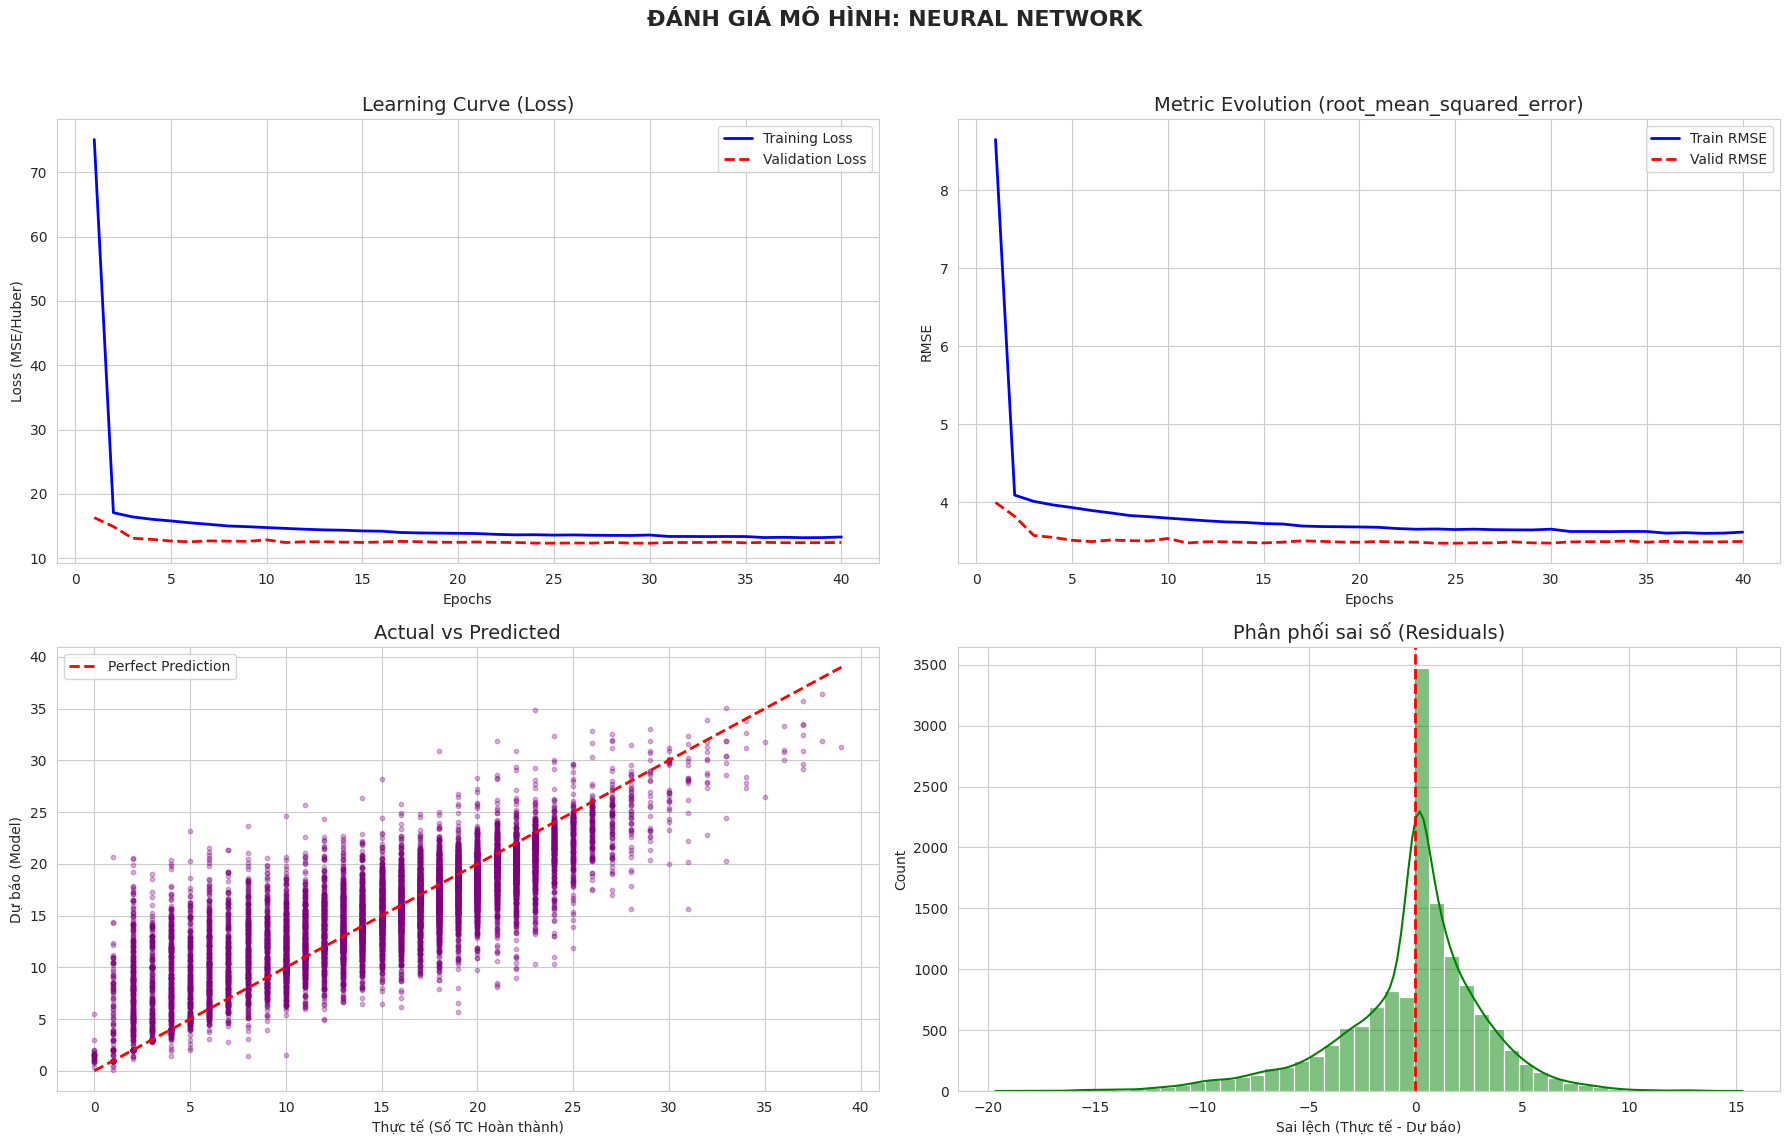

In [9]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

def visualize_training_results(history, y_true, y_pred, model_name="Neural Network"):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f'ĐÁNH GIÁ MÔ HÌNH: {model_name.upper()}', fontsize=16, fontweight='bold')

    # LEARNING CURVE (LOSS)
    loss_train = history.history['loss']
    loss_val = history.history['val_loss']
    epochs = range(1, len(loss_train) + 1)

    axes[0, 0].plot(epochs, loss_train, 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, loss_val, 'r--', label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Learning Curve (Loss)', fontsize=14)
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss (MSE/Huber)')
    axes[0, 0].legend()

    # RMSE CURVE
    rmse_key = 'root_mean_squared_error'
    rmse_train = history.history[rmse_key]
    rmse_val = history.history[f'val_{rmse_key}']

    axes[0, 1].plot(epochs, rmse_train, 'b-', label='Train RMSE', linewidth=2)
    axes[0, 1].plot(epochs, rmse_val, 'r--', label='Valid RMSE', linewidth=2)
    axes[0, 1].set_title(f'Metric Evolution ({rmse_key})', fontsize=14)
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('RMSE')
    axes[0, 1].legend()

    # ACTUAL vs PREDICTED (SCATTER PLOT)
    axes[1, 0].scatter(y_true, y_pred, alpha=0.3, color='purple', s=10)

    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    axes[1, 0].set_title('Actual vs Predicted', fontsize=14)
    axes[1, 0].set_xlabel('Thực tế (Số TC Hoàn thành)')
    axes[1, 0].set_ylabel('Dự báo (Model)')
    axes[1, 0].legend()

    # RESIDUAL DISTRIBUTION (HISTOGRAM)
    residuals = y_true - y_pred
    sns.histplot(residuals, kde=True, ax=axes[1, 1], color='green', bins=50)
    axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_title('Phân phối sai số (Residuals)', fontsize=14)
    axes[1, 1].set_xlabel('Sai lệch (Thực tế - Dự báo)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

visualize_training_results(history, y_valid, pred_valid)